In [60]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.sparse as sp
from tqdm import tqdm

In [61]:
gowalla_path=r"D:\SEM-6\ELECTIVES\DEPARTMENT-ELECTIVES\Recommendation Systems\Project\LightGCN-master\Data\gowalla"
yelp_path=r"D:\SEM-6\ELECTIVES\DEPARTMENT-ELECTIVES\Recommendation Systems\Project\LightGCN-master\Data\yelp2018"
amazon_path=r"D:\SEM-6\ELECTIVES\DEPARTMENT-ELECTIVES\Recommendation Systems\Project\LightGCN-master\Data\amazon-book"

In [62]:
def load_interactions(path, dataset_name=""):
    rows = []
    skipped = []
    with open(path, "r") as f:
        for line_num, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
                
            try:
                parts = list(map(int, line.split()))
                
                if len(parts) < 2:
                    skipped.append(line_num)
                    continue
                
                user = parts[0]
                items = parts[1:]
                
                for item in items:
                    rows.append((user, item))
                    
            except ValueError as e:
                print(f"Error parsing line {line_num}: {line[:50]}")
                skipped.append(line_num)
                continue
    
    if skipped:
        print(f"⚠️ {dataset_name} - Skipped {len(skipped)} invalid lines")
    
    return pd.DataFrame(rows, columns=["user_id", "item_id"])

In [63]:
expected_stats = {
    "Gowalla": {"users": 29858, "items": 40981, "interactions": 1027370},
    "Yelp2018": {"users": 31668, "items": 38048, "interactions": 1561406},
    "Amazon-Book": {"users": 52643, "items": 91599, "interactions": 2984108}
}
print("="*50)
print("Loading Gowalla...")
gowalla_train = load_interactions(os.path.join(gowalla_path, "train.txt"), "Gowalla Train")
gowalla_test  = load_interactions(os.path.join(gowalla_path, "test.txt"), "Gowalla Test")
print(f"Train: {gowalla_train.shape}, Test: {gowalla_test.shape}")

print("="*50)
print("Loading Yelp2018...")
yelp_train = load_interactions(os.path.join(yelp_path, "train.txt"), "Yelp Train")
yelp_test  = load_interactions(os.path.join(yelp_path, "test.txt"), "Yelp Test")
print(f"Train: {yelp_train.shape}, Test: {yelp_test.shape}")

print("="*50)
print("Loading Amazon-Book...")
amazon_train = load_interactions(os.path.join(amazon_path, "train.txt"), "Amazon Train")
amazon_test  = load_interactions(os.path.join(amazon_path, "test.txt"), "Amazon Test")
print(f"Train: {amazon_train.shape}, Test: {amazon_test.shape}")

Loading Gowalla...
Train: (810128, 2), Test: (217242, 2)
Loading Yelp2018...
Train: (1237259, 2), Test: (324147, 2)
Loading Amazon-Book...
⚠️ Amazon Test - Skipped 4 invalid lines
Train: (2380730, 2), Test: (603378, 2)


In [64]:
def check_dataset(train_df, test_df, name):
    total_df = pd.concat([train_df, test_df])
    
    n_users = total_df['user_id'].nunique()
    n_items = total_df['item_id'].nunique()
    n_interactions = len(total_df)
    
    expected = expected_stats[name]
    
    print(f"\n{name}:")
    print(f"  Users: {n_users} (expected: {expected['users']})")
    print(f"  Items: {n_items} (expected: {expected['items']})")
    print(f"  Interactions: {n_interactions} (expected: {expected['interactions']})")
    print(f"  Train: {len(train_df)}, Test: {len(test_df)}")
    
check_dataset(gowalla_train, gowalla_test, "Gowalla")
check_dataset(yelp_train, yelp_test, "Yelp2018")
check_dataset(amazon_train, amazon_test, "Amazon-Book")


Gowalla:
  Users: 29858 (expected: 29858)
  Items: 40981 (expected: 40981)
  Interactions: 1027370 (expected: 1027370)
  Train: 810128, Test: 217242

Yelp2018:
  Users: 31668 (expected: 31668)
  Items: 38048 (expected: 38048)
  Interactions: 1561406 (expected: 1561406)
  Train: 1237259, Test: 324147

Amazon-Book:
  Users: 52643 (expected: 52643)
  Items: 91599 (expected: 91599)
  Interactions: 2984108 (expected: 2984108)
  Train: 2380730, Test: 603378


In [65]:
def dataset_stats(train_df, test_df, name):
    # Combine safely (append is deprecated)
    df = pd.concat([train_df, test_df], ignore_index=True)
    
    n_users = df["user_id"].nunique()
    n_items = df["item_id"].nunique()
    n_interactions = len(df)
    density = n_interactions / (n_users * n_items)
    
    print(f"\n{name}")
    print("-" * 40)
    print(f"Users        : {n_users}")
    print(f"Items        : {n_items}")
    print(f"Interactions : {n_interactions}")
    print(f"Density      : {density:.6f}")


In [66]:
dataset_stats(gowalla_train, gowalla_test, "Gowalla")
dataset_stats(yelp_train, yelp_test, "Yelp2018")
dataset_stats(amazon_train, amazon_test, "Amazon-Book")


Gowalla
----------------------------------------
Users        : 29858
Items        : 40981
Interactions : 1027370
Density      : 0.000840

Yelp2018
----------------------------------------
Users        : 31668
Items        : 38048
Interactions : 1561406
Density      : 0.001296

Amazon-Book
----------------------------------------
Users        : 52643
Items        : 91599
Interactions : 2984108
Density      : 0.000619


In [67]:
def degree_eda(train_df, name):
    # User degree
    user_deg = train_df.groupby("user_id").size()
    
    # Item degree
    item_deg = train_df.groupby("item_id").size()
    
    print(f"\n{name} — USER DEGREE STATS")
    print("-" * 50)
    print(user_deg.describe())
    
    print(f"\n{name} — ITEM DEGREE STATS")
    print("-" * 50)
    print(item_deg.describe())
    
    print(f"\n{name} — LONG-TAIL CHECK")
    print("-" * 50)
    print("Users with ≤ 5 interactions :", (user_deg <= 5).sum())
    print("Items with ≤ 5 interactions :", (item_deg <= 5).sum())
    print("Items with ≥ 100 interactions:", (item_deg >= 100).sum())
    
    return user_deg, item_deg


In [68]:
gowalla_user_deg, gowalla_item_deg = degree_eda(gowalla_train, "Gowalla")


Gowalla — USER DEGREE STATS
--------------------------------------------------
count    29858.000000
mean        27.132695
std         36.858805
min          8.000000
25%         11.000000
50%         16.000000
75%         29.000000
max        811.000000
dtype: float64

Gowalla — ITEM DEGREE STATS
--------------------------------------------------
count    40981.000000
mean        19.768380
std         33.113085
min          1.000000
25%          9.000000
50%         12.000000
75%         19.000000
max       1415.000000
dtype: float64

Gowalla — LONG-TAIL CHECK
--------------------------------------------------
Users with ≤ 5 interactions : 0
Items with ≤ 5 interactions : 606
Items with ≥ 100 interactions: 728


In [69]:
yelp_user_deg, yelp_item_deg       = degree_eda(yelp_train, "Yelp2018")


Yelp2018 — USER DEGREE STATS
--------------------------------------------------
count    31668.000000
mean        39.069692
std         45.109014
min         16.000000
25%         19.000000
50%         25.000000
75%         41.000000
max       1848.000000
dtype: float64

Yelp2018 — ITEM DEGREE STATS
--------------------------------------------------
count    38048.000000
mean        32.518372
std         49.266678
min          1.000000
25%         11.000000
50%         17.000000
75%         34.000000
max       1258.000000
dtype: float64

Yelp2018 — LONG-TAIL CHECK
--------------------------------------------------
Users with ≤ 5 interactions : 0
Items with ≤ 5 interactions : 1126
Items with ≥ 100 interactions: 2207


In [70]:
amazon_user_deg, amazon_item_deg   = degree_eda(amazon_train, "Amazon-Book")


Amazon-Book — USER DEGREE STATS
--------------------------------------------------
count    52643.000000
mean        45.224056
std         77.958253
min         16.000000
25%         19.000000
50%         26.000000
75%         45.000000
max      10682.000000
dtype: float64

Amazon-Book — ITEM DEGREE STATS
--------------------------------------------------
count    91599.000000
mean        25.990786
std         38.397318
min          1.000000
25%         10.000000
50%         15.000000
75%         28.000000
max       1741.000000
dtype: float64

Amazon-Book — LONG-TAIL CHECK
--------------------------------------------------
Users with ≤ 5 interactions : 0
Items with ≤ 5 interactions : 4393
Items with ≥ 100 interactions: 2806


In [71]:
def train_test_consistency(train_df, test_df, name):
    print(f"\n{name} — TRAIN–TEST CONSISTENCY CHECK")
    print("-" * 60)
    
    # 1. User overlap
    train_users = set(train_df["user_id"].unique())
    test_users  = set(test_df["user_id"].unique())
    
    print("Users in train:", len(train_users))
    print("Users in test :", len(test_users))
    print("Test users ⊆ train users:", test_users.issubset(train_users))
    
    # 2. Item leakage check
    train_pairs = set(zip(train_df.user_id, train_df.item_id))
    test_pairs  = set(zip(test_df.user_id, test_df.item_id))
    
    leakage = len(train_pairs & test_pairs)
    print("Train–test interaction leakage:", leakage)
    
    # 3. Test items per user
    test_per_user = test_df.groupby("user_id").size()
    
    print("\nTest items per user:")
    print(test_per_user.describe())
    
    # 4. Explicit protocol check
    if test_per_user.min() == 1 and test_per_user.max() == 1:
        print("✔ Leave-one-out evaluation (exactly 1 test item per user)")
    else:
        print("✔ Multiple test items per user (handled correctly for Amazon-Book)")


In [72]:
train_test_consistency(gowalla_train, gowalla_test, "Gowalla")


Gowalla — TRAIN–TEST CONSISTENCY CHECK
------------------------------------------------------------
Users in train: 29858
Users in test : 29858
Test users ⊆ train users: True
Train–test interaction leakage: 0

Test items per user:
count    29858.000000
mean         7.275839
std          9.217185
min          1.000000
25%          3.000000
50%          4.000000
75%          8.000000
max        203.000000
dtype: float64
✔ Multiple test items per user (handled correctly for Amazon-Book)


In [73]:
train_test_consistency(yelp_train, yelp_test, "Yelp2018")


Yelp2018 — TRAIN–TEST CONSISTENCY CHECK
------------------------------------------------------------
Users in train: 31668
Users in test : 31668
Test users ⊆ train users: True
Train–test interaction leakage: 0

Test items per user:
count    31668.000000
mean        10.235790
std         11.245533
min          2.000000
25%          5.000000
50%          7.000000
75%         11.000000
max        463.000000
dtype: float64
✔ Multiple test items per user (handled correctly for Amazon-Book)


In [74]:
train_test_consistency(amazon_train, amazon_test, "Amazon-Book")


Amazon-Book — TRAIN–TEST CONSISTENCY CHECK
------------------------------------------------------------
Users in train: 52643
Users in test : 52639
Test users ⊆ train users: True
Train–test interaction leakage: 0

Test items per user:
count    52639.000000
mean        11.462566
std         18.934040
min          1.000000
25%          5.000000
50%          7.000000
75%         12.000000
max       2631.000000
dtype: float64
✔ Multiple test items per user (handled correctly for Amazon-Book)


In [75]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)
def plot_degree_distributions(train_df, name):
    user_deg = train_df.groupby("user_id").size()
    item_deg = train_df.groupby("item_id").size()
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'{name} - Degree Distributions', fontsize=16, fontweight='bold')
    
    # User distributions
    # Histogram
    axes[0, 0].hist(user_deg, bins=50, edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Number of Interactions')
    axes[0, 0].set_ylabel('Number of Users')
    axes[0, 0].set_title('User Degree Histogram')
    axes[0, 0].axvline(user_deg.mean(), color='red', linestyle='--', label=f'Mean: {user_deg.mean():.1f}')
    axes[0, 0].legend()
    
    # Log-scale histogram
    axes[0, 1].hist(user_deg, bins=50, edgecolor='black', alpha=0.7)
    axes[0, 1].set_xlabel('Number of Interactions')
    axes[0, 1].set_ylabel('Number of Users (log scale)')
    axes[0, 1].set_title('User Degree Histogram (Log Scale)')
    axes[0, 1].set_yscale('log')
    
    # CDF
    sorted_user = np.sort(user_deg)
    cdf = np.arange(1, len(sorted_user) + 1) / len(sorted_user)
    axes[0, 2].plot(sorted_user, cdf, linewidth=2)
    axes[0, 2].set_xlabel('Number of Interactions')
    axes[0, 2].set_ylabel('Cumulative Probability')
    axes[0, 2].set_title('User Degree CDF')
    axes[0, 2].grid(True, alpha=0.3)
    
    # Item distributions
    # Histogram
    axes[1, 0].hist(item_deg, bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[1, 0].set_xlabel('Number of Interactions')
    axes[1, 0].set_ylabel('Number of Items')
    axes[1, 0].set_title('Item Degree Histogram')
    axes[1, 0].axvline(item_deg.mean(), color='red', linestyle='--', label=f'Mean: {item_deg.mean():.1f}')
    axes[1, 0].legend()
    
    # Log-log plot (power law check)
    item_counts = item_deg.value_counts().sort_index()
    axes[1, 1].scatter(item_counts.index, item_counts.values, alpha=0.6, color='orange')
    axes[1, 1].set_xlabel('Degree (log scale)')
    axes[1, 1].set_ylabel('Frequency (log scale)')
    axes[1, 1].set_title('Item Degree Log-Log Plot (Power Law Check)')
    axes[1, 1].set_xscale('log')
    axes[1, 1].set_yscale('log')
    axes[1, 1].grid(True, alpha=0.3)
    
    # CDF
    sorted_item = np.sort(item_deg)
    cdf = np.arange(1, len(sorted_item) + 1) / len(sorted_item)
    axes[1, 2].plot(sorted_item, cdf, linewidth=2, color='orange')
    axes[1, 2].set_xlabel('Number of Interactions')
    axes[1, 2].set_ylabel('Cumulative Probability')
    axes[1, 2].set_title('Item Degree CDF')
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return user_deg, item_deg

Generating distribution plots...



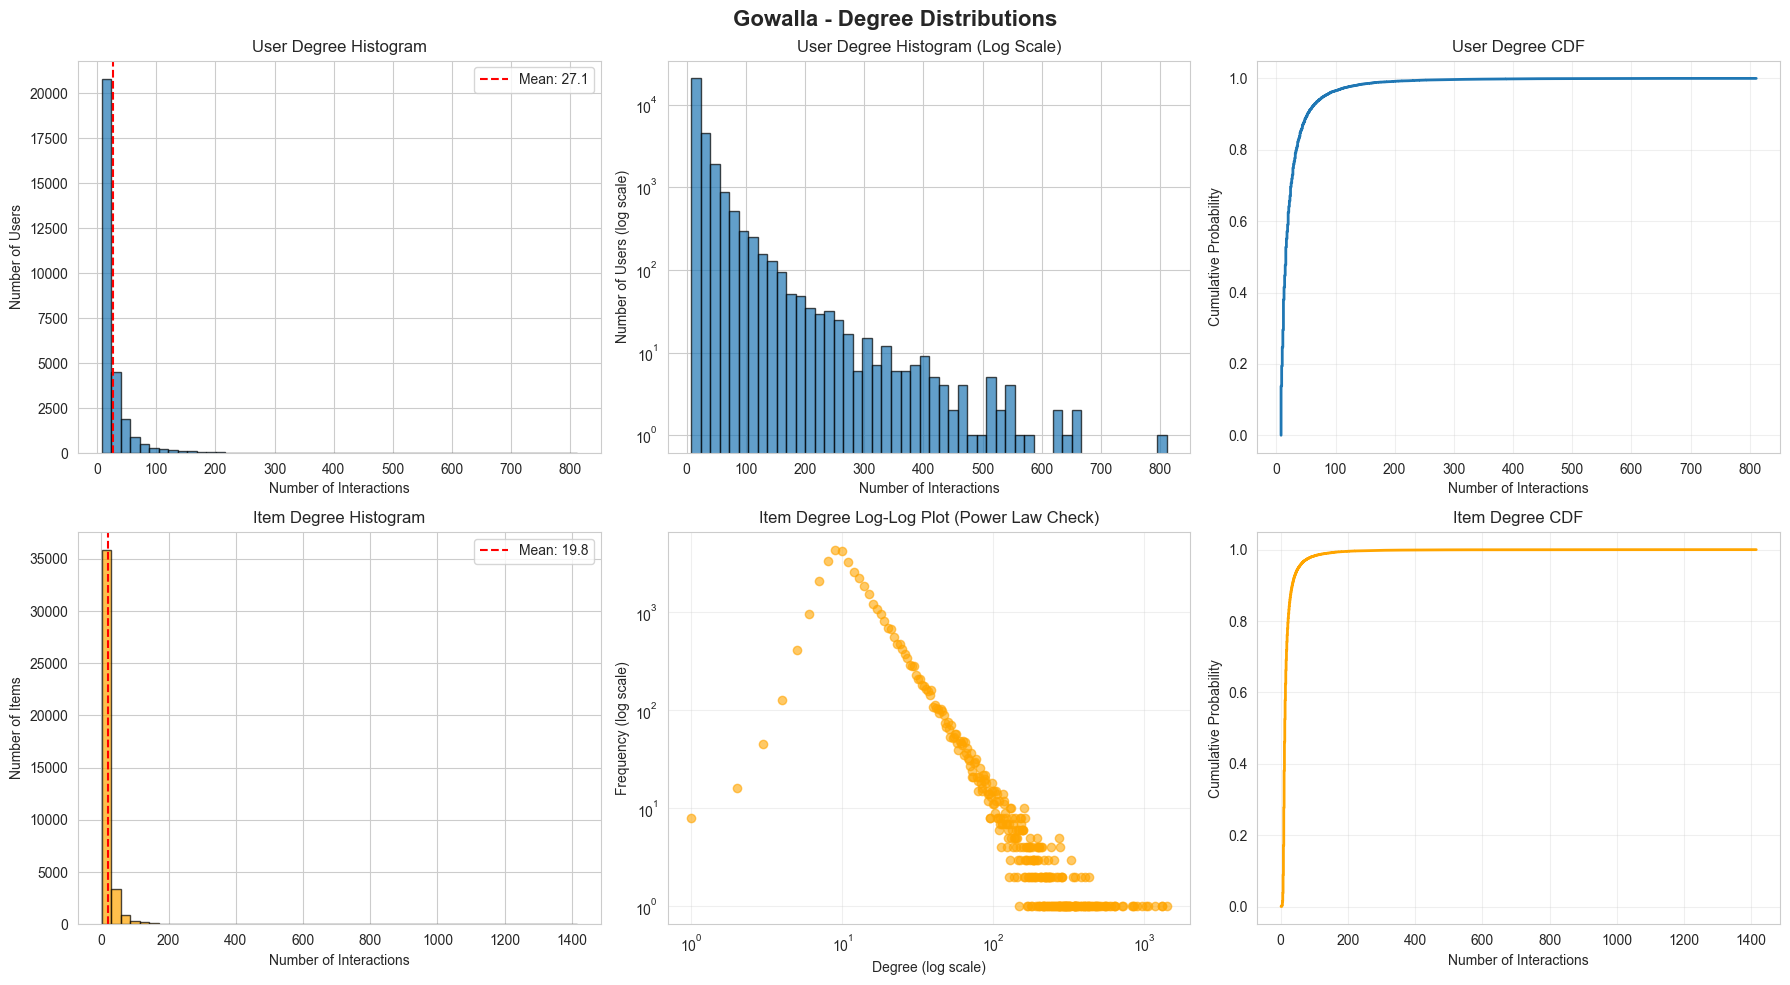

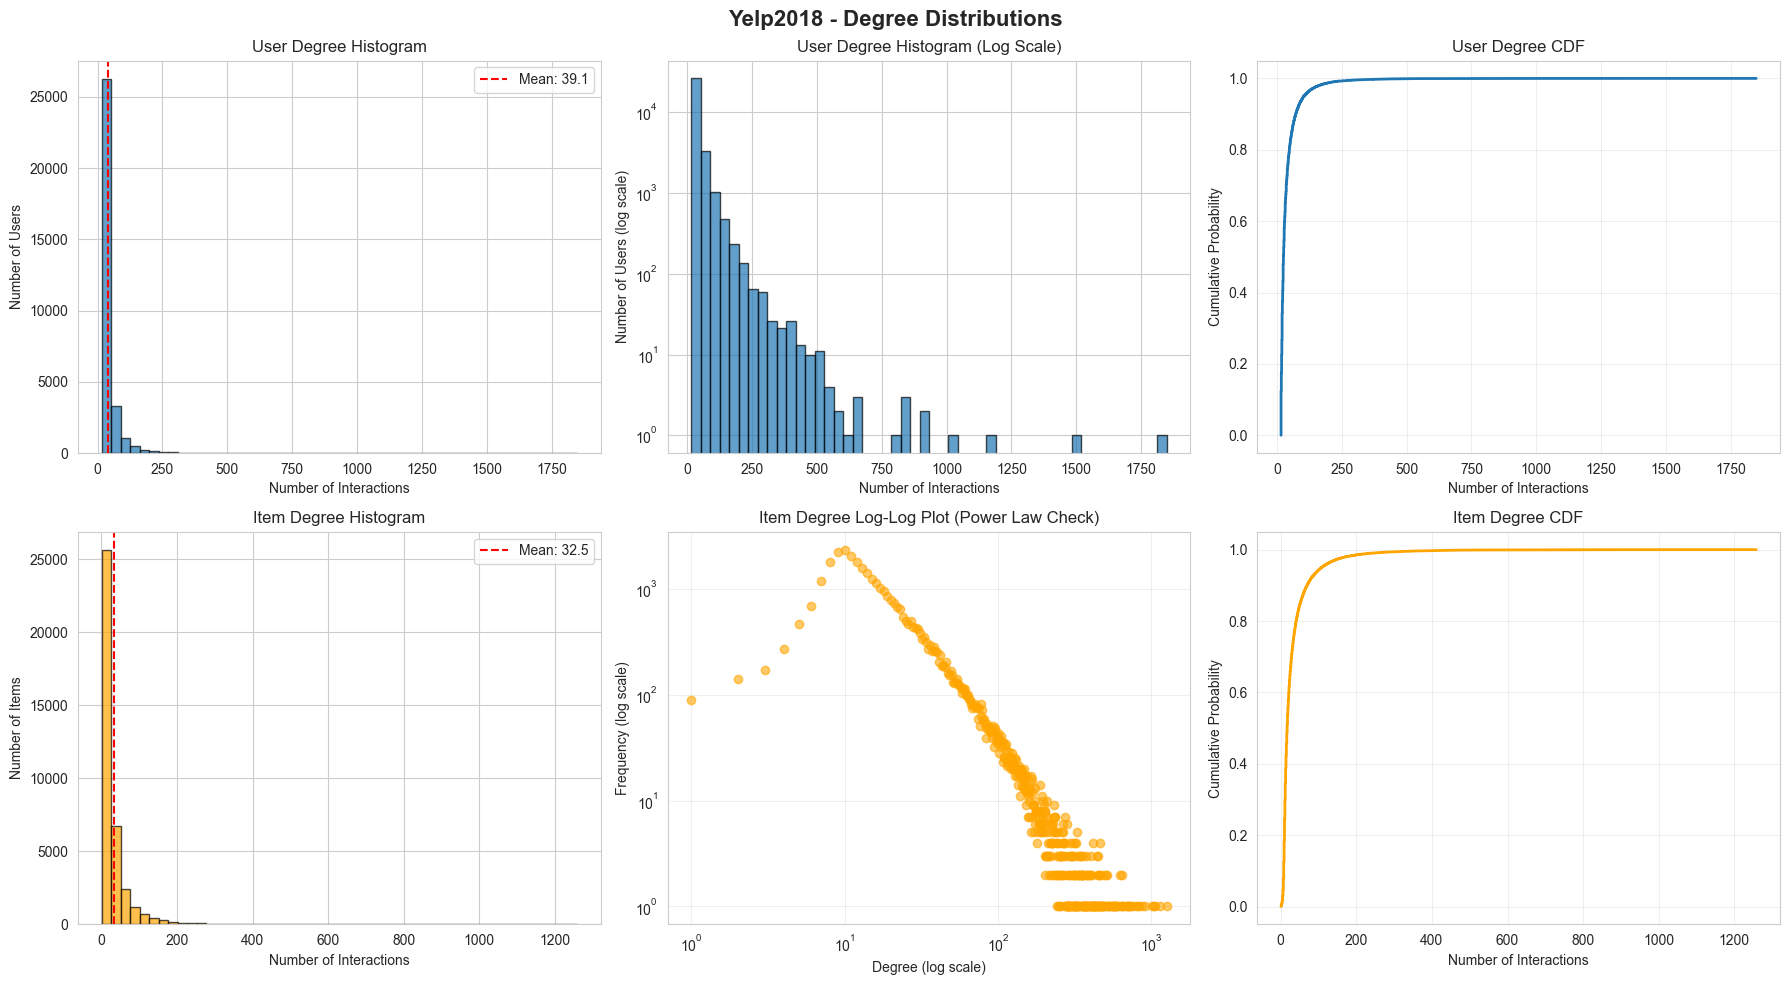

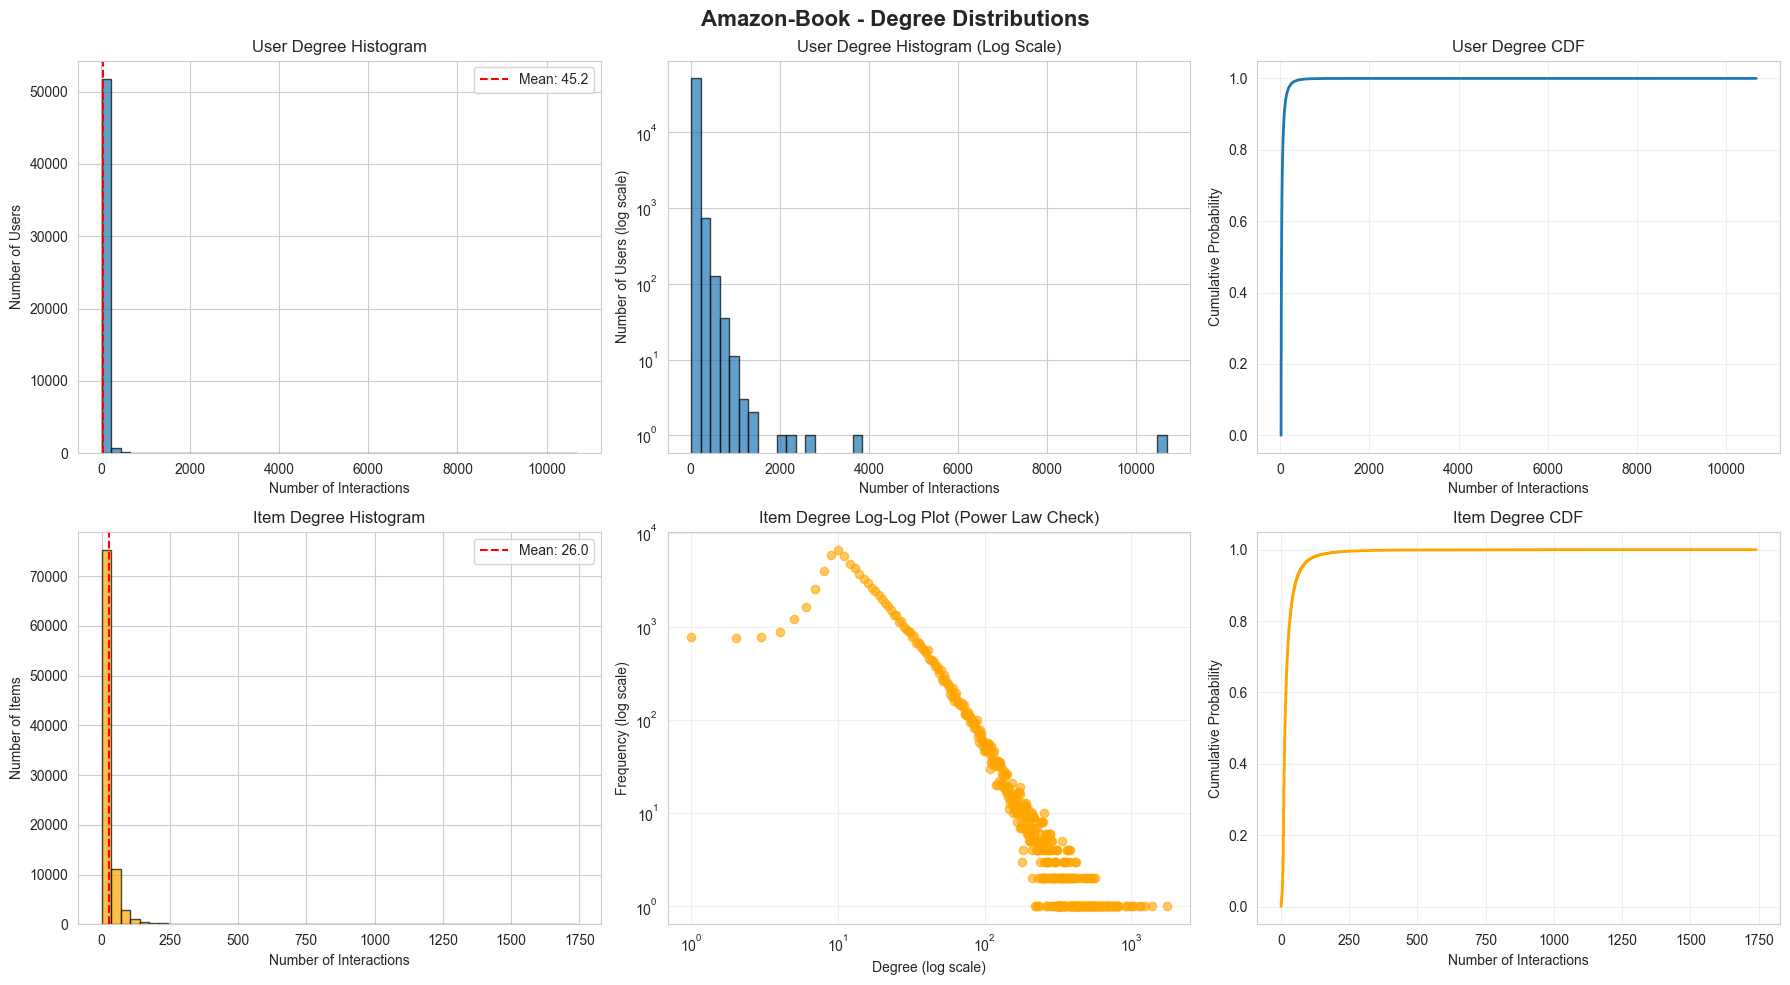

In [76]:
print("Generating distribution plots...\n")
gowalla_user, gowalla_item = plot_degree_distributions(gowalla_train, "Gowalla")
yelp_user, yelp_item = plot_degree_distributions(yelp_train, "Yelp2018")
amazon_user, amazon_item = plot_degree_distributions(amazon_train, "Amazon-Book")

In [77]:
def sparsity_analysis(train_df, test_df, name):
    """Analyze sparsity patterns"""
    df = pd.concat([train_df, test_df])
    
    n_users = df['user_id'].nunique()
    n_items = df['item_id'].nunique()
    n_interactions = len(df)
    
    sparsity = 1 - (n_interactions / (n_users * n_items))
    
    print(f"\n{'='*60}")
    print(f"{name} - SPARSITY ANALYSIS")
    print(f"{'='*60}")
    print(f"Total possible interactions: {n_users * n_items:,}")
    print(f"Actual interactions:         {n_interactions:,}")
    print(f"Sparsity:                    {sparsity:.6f} ({sparsity*100:.4f}%)")
    print(f"Density:                     {1-sparsity:.6f} ({(1-sparsity)*100:.4f}%)")
    
    # User activity levels
    user_deg = train_df.groupby("user_id").size()
    print(f"\n{name} - USER ACTIVITY LEVELS")
    print("-" * 60)
    print(f"Very sparse users (≤5 items):    {(user_deg <= 5).sum():,} ({(user_deg <= 5).sum()/len(user_deg)*100:.2f}%)")
    print(f"Sparse users (6-20 items):       {((user_deg > 5) & (user_deg <= 20)).sum():,}")
    print(f"Active users (21-50 items):      {((user_deg > 20) & (user_deg <= 50)).sum():,}")
    print(f"Very active users (>50 items):   {(user_deg > 50).sum():,}")
    
    # Item popularity levels
    item_deg = train_df.groupby("item_id").size()
    print(f"\n{name} - ITEM POPULARITY LEVELS")
    print("-" * 60)
    print(f"Cold items (≤5 users):           {(item_deg <= 5).sum():,} ({(item_deg <= 5).sum()/len(item_deg)*100:.2f}%)")
    print(f"Niche items (6-20 users):        {((item_deg > 5) & (item_deg <= 20)).sum():,}")
    print(f"Popular items (21-100 users):    {((item_deg > 20) & (item_deg <= 100)).sum():,}")
    print(f"Very popular items (>100 users): {(item_deg > 100).sum():,}")
    
    return user_deg, item_deg

In [78]:
gowalla_u, gowalla_i = sparsity_analysis(gowalla_train, gowalla_test, "Gowalla")


Gowalla - SPARSITY ANALYSIS
Total possible interactions: 1,223,610,698
Actual interactions:         1,027,370
Sparsity:                    0.999160 (99.9160%)
Density:                     0.000840 (0.0840%)

Gowalla - USER ACTIVITY LEVELS
------------------------------------------------------------
Very sparse users (≤5 items):    0 (0.00%)
Sparse users (6-20 items):       18,654
Active users (21-50 items):      7,972
Very active users (>50 items):   3,232

Gowalla - ITEM POPULARITY LEVELS
------------------------------------------------------------
Cold items (≤5 users):           606 (1.48%)
Niche items (6-20 users):        31,298
Popular items (21-100 users):    8,360
Very popular items (>100 users): 717


In [79]:
yelp_u, yelp_i = sparsity_analysis(yelp_train, yelp_test, "Yelp2018")


Yelp2018 - SPARSITY ANALYSIS
Total possible interactions: 1,204,904,064
Actual interactions:         1,561,406
Sparsity:                    0.998704 (99.8704%)
Density:                     0.001296 (0.1296%)

Yelp2018 - USER ACTIVITY LEVELS
------------------------------------------------------------
Very sparse users (≤5 items):    0 (0.00%)
Sparse users (6-20 items):       10,842
Active users (21-50 items):      14,984
Very active users (>50 items):   5,842

Yelp2018 - ITEM POPULARITY LEVELS
------------------------------------------------------------
Cold items (≤5 users):           1,126 (2.96%)
Niche items (6-20 users):        20,937
Popular items (21-100 users):    13,821
Very popular items (>100 users): 2,164


In [80]:
amazon_u, amazon_i = sparsity_analysis(amazon_train, amazon_test, "Amazon-Book")


Amazon-Book - SPARSITY ANALYSIS
Total possible interactions: 4,822,046,157
Actual interactions:         2,984,108
Sparsity:                    0.999381 (99.9381%)
Density:                     0.000619 (0.0619%)

Amazon-Book - USER ACTIVITY LEVELS
------------------------------------------------------------
Very sparse users (≤5 items):    0 (0.00%)
Sparse users (6-20 items):       17,098
Active users (21-50 items):      23,987
Very active users (>50 items):   11,558

Amazon-Book - ITEM POPULARITY LEVELS
------------------------------------------------------------
Cold items (≤5 users):           4,393 (4.80%)
Niche items (6-20 users):        54,215
Popular items (21-100 users):    30,242
Very popular items (>100 users): 2,749


In [81]:
def graph_structure_safe(train_df, name):
    print(f"\n{'='*60}")
    print(f"{name} — GRAPH STRUCTURE (SAFE, PAPER-FAITHFUL)")
    print(f"{'='*60}")
    
    n_users = train_df["user_id"].nunique()
    n_items = train_df["item_id"].nunique()
    n_edges = len(train_df)
    
    user_deg = train_df.groupby("user_id").size()
    item_deg = train_df.groupby("item_id").size()
    
    print(f"Users          : {n_users:,}")
    print(f"Items          : {n_items:,}")
    print(f"Total nodes    : {n_users + n_items:,}")
    print(f"Interactions   : {n_edges:,}")
    
    print("\nDegree statistics")
    print("-" * 40)
    print(f"Avg user degree: {user_deg.mean():.2f}")
    print(f"Avg item degree: {item_deg.mean():.2f}")
    
    print("\nIsolated node check")
    print("-" * 40)
    print("Users with 0 interactions:", (user_deg == 0).sum())
    print("Items with 0 interactions:", (item_deg == 0).sum())


In [82]:
graph_structure_safe(gowalla_train, "Gowalla Train")
graph_structure_safe(gowalla_test, "Gowalla Test")


Gowalla Train — GRAPH STRUCTURE (SAFE, PAPER-FAITHFUL)
Users          : 29,858
Items          : 40,981
Total nodes    : 70,839
Interactions   : 810,128

Degree statistics
----------------------------------------
Avg user degree: 27.13
Avg item degree: 19.77

Isolated node check
----------------------------------------
Users with 0 interactions: 0
Items with 0 interactions: 0

Gowalla Test — GRAPH STRUCTURE (SAFE, PAPER-FAITHFUL)
Users          : 29,858
Items          : 38,546
Total nodes    : 68,404
Interactions   : 217,242

Degree statistics
----------------------------------------
Avg user degree: 7.28
Avg item degree: 5.64

Isolated node check
----------------------------------------
Users with 0 interactions: 0
Items with 0 interactions: 0


In [83]:
graph_structure_safe(yelp_train, "Yelp Train")
graph_structure_safe(yelp_test, "Yelp Test")


Yelp Train — GRAPH STRUCTURE (SAFE, PAPER-FAITHFUL)
Users          : 31,668
Items          : 38,048
Total nodes    : 69,716
Interactions   : 1,237,259

Degree statistics
----------------------------------------
Avg user degree: 39.07
Avg item degree: 32.52

Isolated node check
----------------------------------------
Users with 0 interactions: 0
Items with 0 interactions: 0

Yelp Test — GRAPH STRUCTURE (SAFE, PAPER-FAITHFUL)
Users          : 31,668
Items          : 36,073
Total nodes    : 67,741
Interactions   : 324,147

Degree statistics
----------------------------------------
Avg user degree: 10.24
Avg item degree: 8.99

Isolated node check
----------------------------------------
Users with 0 interactions: 0
Items with 0 interactions: 0


In [84]:
graph_structure_safe(amazon_train, "Amazon Train")
graph_structure_safe(amazon_test, "Amazon Test")


Amazon Train — GRAPH STRUCTURE (SAFE, PAPER-FAITHFUL)
Users          : 52,643
Items          : 91,599
Total nodes    : 144,242
Interactions   : 2,380,730

Degree statistics
----------------------------------------
Avg user degree: 45.22
Avg item degree: 25.99

Isolated node check
----------------------------------------
Users with 0 interactions: 0
Items with 0 interactions: 0

Amazon Test — GRAPH STRUCTURE (SAFE, PAPER-FAITHFUL)
Users          : 52,639
Items          : 82,629
Total nodes    : 135,268
Interactions   : 603,378

Degree statistics
----------------------------------------
Avg user degree: 11.46
Avg item degree: 7.30

Isolated node check
----------------------------------------
Users with 0 interactions: 0
Items with 0 interactions: 0


In [85]:
def cold_start_analysis(train_df, test_df, name):
    print(f"\n{'='*60}")
    print(f"{name} - COLD START ANALYSIS")
    print(f"{'='*60}")
    
    train_users = set(train_df['user_id'].unique())
    train_items = set(train_df['item_id'].unique())
    test_users = set(test_df['user_id'].unique())
    test_items = set(test_df['item_id'].unique())
    
    # User cold start
    cold_users = test_users - train_users
    print(f"\nCold-start users in test: {len(cold_users)}")
    
    # Item cold start
    cold_items = test_items - train_items
    print(f"Cold-start items in test: {len(cold_items)}")
    
    # Warm start degree distribution
    user_deg = train_df.groupby("user_id").size()
    item_deg = train_df.groupby("item_id").size()
    
    # Users in test and their training degrees
    test_user_degrees = user_deg[user_deg.index.isin(test_users)]
    
    print(f"\nTest users' training interaction stats:")
    print(f"  Min:    {test_user_degrees.min()}")
    print(f"  Max:    {test_user_degrees.max()}")
    print(f"  Mean:   {test_user_degrees.mean():.2f}")
    print(f"  Median: {test_user_degrees.median():.2f}")
    
    # Histogram of test user degrees
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    ax.hist(test_user_degrees, bins=50, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Number of Training Interactions')
    ax.set_ylabel('Number of Test Users')
    ax.set_title(f'{name} - Test Users Training Activity Distribution')
    ax.axvline(test_user_degrees.mean(), color='red', linestyle='--', 
               label=f'Mean: {test_user_degrees.mean():.1f}')
    ax.legend()
    plt.tight_layout()
    plt.show()


Gowalla - COLD START ANALYSIS

Cold-start users in test: 0
Cold-start items in test: 0

Test users' training interaction stats:
  Min:    8
  Max:    811
  Mean:   27.13
  Median: 16.00


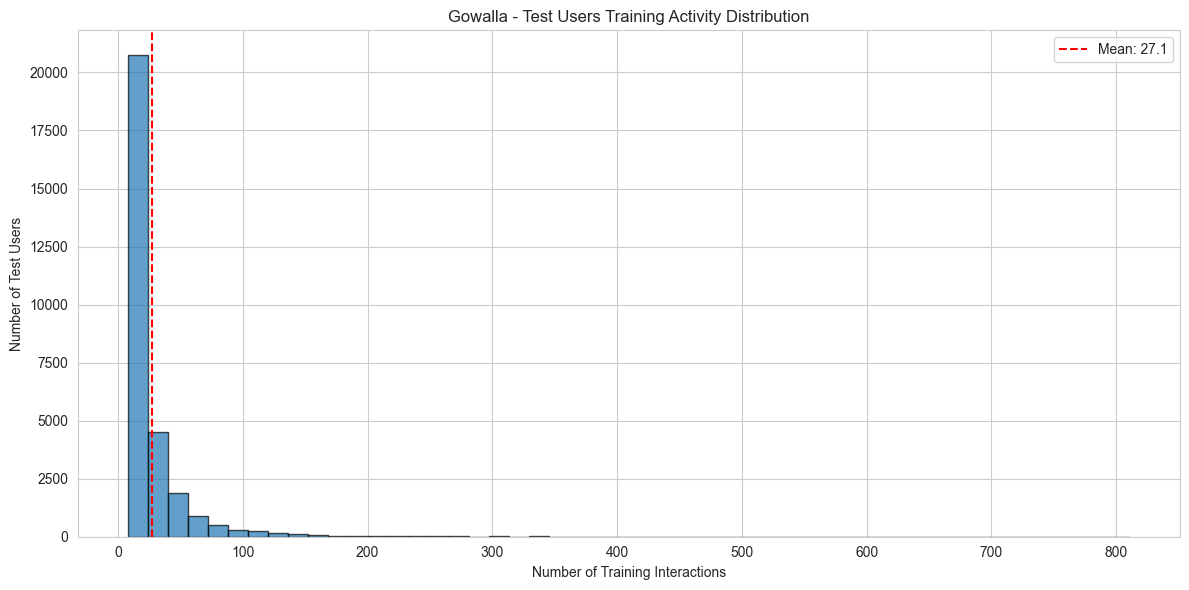


Yelp2018 - COLD START ANALYSIS

Cold-start users in test: 0
Cold-start items in test: 0

Test users' training interaction stats:
  Min:    16
  Max:    1848
  Mean:   39.07
  Median: 25.00


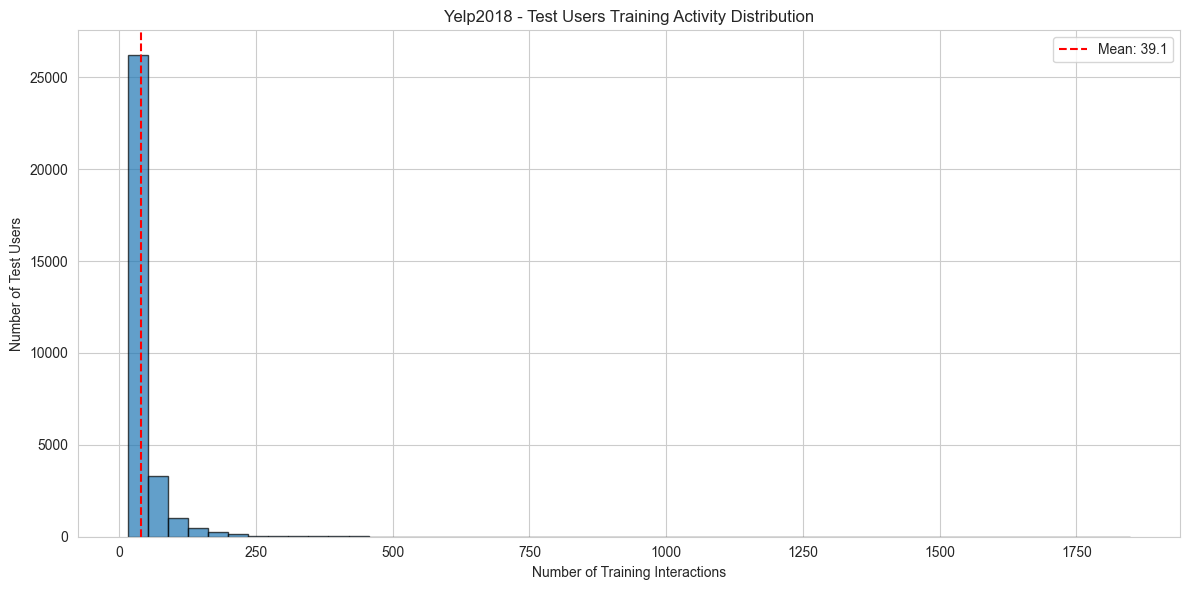


Amazon-Book - COLD START ANALYSIS

Cold-start users in test: 0
Cold-start items in test: 0

Test users' training interaction stats:
  Min:    16
  Max:    10682
  Mean:   45.23
  Median: 26.00


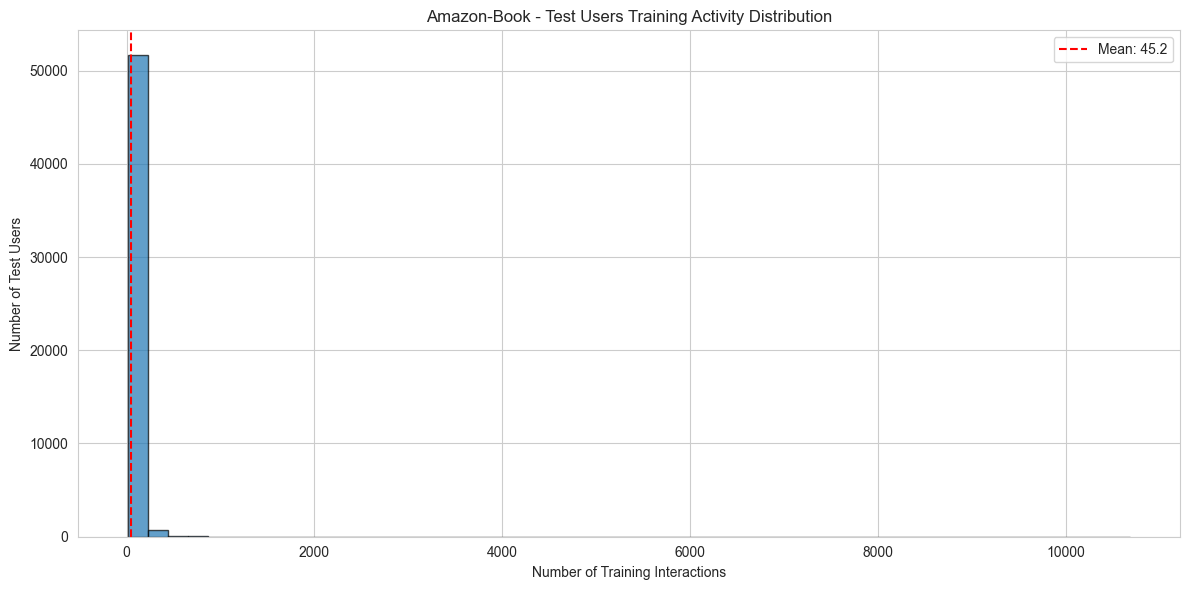

In [86]:
cold_start_analysis(gowalla_train, gowalla_test, "Gowalla")
cold_start_analysis(yelp_train, yelp_test, "Yelp2018")
cold_start_analysis(amazon_train, amazon_test, "Amazon-Book")

In [87]:
def create_summary_table():
    """Create final summary table matching paper format"""
    datasets = {
        'Gowalla': (gowalla_train, gowalla_test),
        'Yelp2018': (yelp_train, yelp_test),
        'Amazon-Book': (amazon_train, amazon_test)
    }
    
    summary = []
    for name, (train, test) in datasets.items():
        df = pd.concat([train, test])
        n_users = df['user_id'].nunique()
        n_items = df['item_id'].nunique()
        n_interactions = len(df)
        density = n_interactions / (n_users * n_items)
        
        summary.append({
            'Dataset': name,
            'Users': f"{n_users:,}",
            'Items': f"{n_items:,}",
            'Interactions': f"{n_interactions:,}",
            'Density': f"{density:.5f}",
            'Train': f"{len(train):,}",
            'Test': f"{len(test):,}"
        })
    
    summary_df = pd.DataFrame(summary)
    
    print("\n" + "="*100)
    print("FINAL SUMMARY TABLE (Table 2 from Paper)")
    print("="*100)
    print(summary_df.to_string(index=False))
    print("="*100)
    
    return summary_df

final_summary = create_summary_table()

print("\n✅ EDA Complete!")


FINAL SUMMARY TABLE (Table 2 from Paper)
    Dataset  Users  Items Interactions Density     Train    Test
    Gowalla 29,858 40,981    1,027,370 0.00084   810,128 217,242
   Yelp2018 31,668 38,048    1,561,406 0.00130 1,237,259 324,147
Amazon-Book 52,643 91,599    2,984,108 0.00062 2,380,730 603,378

✅ EDA Complete!


In [88]:
train_df = gowalla_train.copy()

# Reindex users
unique_users = train_df['user_id'].unique()
user2id = {u: i for i, u in enumerate(unique_users)}

# Reindex items
unique_items = train_df['item_id'].unique()
item2id = {i: j for j, i in enumerate(unique_items)}

# Apply mapping
train_df['user_id'] = train_df['user_id'].map(user2id)
train_df['item_id'] = train_df['item_id'].map(item2id)

n_users = len(user2id)
n_items = len(item2id)

print("Users:", n_users)
print("Items:", n_items)


Users: 29858
Items: 40981


In [89]:
# Row indices = users
rows = train_df['user_id'].values

# Column indices = items
cols = train_df['item_id'].values

# Values = 1 (implicit feedback)
data = np.ones(len(train_df), dtype=np.float32)

# Sparse user–item matrix
R = sp.coo_matrix(
    (data, (rows, cols)),
    shape=(n_users, n_items)
)

print("R shape:", R.shape)
print("Non-zero entries:", R.nnz)

R shape: (29858, 40981)
Non-zero entries: 810128


In [90]:
# Upper-right block (users → items)
upper = R

# Lower-left block (items → users)
lower = R.T

# Zero blocks
zero_u = sp.coo_matrix((n_users, n_users))
zero_i = sp.coo_matrix((n_items, n_items))

# Full adjacency matrix
A = sp.bmat(
    [[zero_u, upper],
     [lower,  zero_i]],
    format="coo"
)

print("A shape:", A.shape)
print("A non-zeros:", A.nnz)

A shape: (70839, 70839)
A non-zeros: 1620256


In [91]:
# Degree of each node
degree = np.array(A.sum(axis=1)).flatten()

print("Degree vector shape:", degree.shape)
print("Min degree:", degree.min())
print("Max degree:", degree.max())

Degree vector shape: (70839,)
Min degree: 1.0
Max degree: 1415.0


In [92]:
# Inverse sqrt degree
deg_inv_sqrt = np.power(degree, -0.5)

# Handle numerical safety
deg_inv_sqrt[np.isinf(deg_inv_sqrt)] = 0.0


In [93]:
# Convert to diagonal matrix
D_inv_sqrt = sp.diags(deg_inv_sqrt)

# Normalized adjacency
A_norm = D_inv_sqrt @ A @ D_inv_sqrt

print("A_norm shape:", A_norm.shape)
print("A_norm non-zeros:", A_norm.nnz)


A_norm shape: (70839, 70839)
A_norm non-zeros: 1620256


In [94]:
# Embedding dimension (paper setting)
d = 64

# Total nodes = users + items
n_nodes = n_users + n_items

# Random initialization
np.random.seed(42)
E0 = np.random.normal(
    loc=0.0,
    scale=0.01,
    size=(n_nodes, d)
).astype(np.float32)

print("E0 shape:", E0.shape)

E0 shape: (70839, 64)


In [95]:
# First graph propagation
E1 = A_norm.dot(E0)

print("E1 shape:", E1.shape)

E1 shape: (70839, 64)


In [96]:
def propagate_embeddings(A_norm, E0, K):
    """
    Perform K-step LightGCN propagation
    Returns list: [E^(0), E^(1), ..., E^(K)]
    """
    embeddings = [E0]
    Ek = E0
    
    for k in range(1, K + 1):
        Ek = A_norm.dot(Ek)
        embeddings.append(Ek)
        print(f"Computed E^{k}, shape = {Ek.shape}")
    
    return embeddings

In [97]:
K = 3
E_layers = propagate_embeddings(A_norm, E0, K)


Computed E^1, shape = (70839, 64)
Computed E^2, shape = (70839, 64)
Computed E^3, shape = (70839, 64)


In [98]:
# Stack and average
E_final = np.mean(E_layers, axis=0)

print("Final embedding shape:", E_final.shape)

Final embedding shape: (70839, 64)


In [99]:
# User embeddings
E_user = E_final[:n_users]

# Item embeddings
E_item = E_final[n_users:]

print("User embedding shape:", E_user.shape)
print("Item embedding shape:", E_item.shape)

User embedding shape: (29858, 64)
Item embedding shape: (40981, 64)


In [100]:
def predict_score(user_id, item_id, E_user, E_item):
    return np.dot(E_user[user_id], E_item[item_id])


In [101]:
u = 0
i = 0
print("Sample prediction:", predict_score(u, i, E_user, E_item))

Sample prediction: 8.514941674889982e-06


In [102]:
# Build user -> set of positive items (from TRAIN only)
from collections import defaultdict

user_pos_items = defaultdict(set)

for u, i in zip(train_df['user_id'], train_df['item_id']):
    user_pos_items[u].add(i)

n_items = E_item.shape[0]

print("Example user positives:", list(user_pos_items.items())[:1])

Example user positives: [(0, {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126})]


In [103]:
import random

def sample_triplet(user_pos_items, n_items):
    """
    Sample (u, i, j)
    u: user
    i: positive item
    j: negative item (not interacted)
    """
    u = random.choice(list(user_pos_items.keys()))
    i = random.choice(list(user_pos_items[u]))
    
    while True:
        j = random.randint(0, n_items - 1)
        if j not in user_pos_items[u]:
            break
            
    return u, i, j


In [104]:
u, i, j = sample_triplet(user_pos_items, n_items)
print(u, i, j)

28201 2263 19182


In [105]:
def bpr_loss(u, i, j, E_user, E_item, reg=1e-4):
    """
    Compute BPR loss for one triplet
    """
    x_ui = np.dot(E_user[u], E_item[i])
    x_uj = np.dot(E_user[u], E_item[j])
    
    loss = -np.log(1e-10 + 1 / (1 + np.exp(-(x_ui - x_uj))))
    
    # L2 regularization (only on initial embeddings conceptually)
    reg_term = reg * (
        np.linalg.norm(E_user[u])**2 +
        np.linalg.norm(E_item[i])**2 +
        np.linalg.norm(E_item[j])**2
    )
    
    return loss + reg_term

In [106]:
print("Sample BPR loss:", bpr_loss(u, i, j, E_user, E_item))

Sample BPR loss: 0.6931319403838796


In [107]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [108]:
import numpy as np
import torch

print("NumPy version:", np.__version__)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

NumPy version: 1.26.4
Torch version: 2.0.1+cu118
CUDA available: True


In [109]:
def scipy_to_torch_sparse(mat):
    mat = mat.tocoo()
    indices = torch.from_numpy(
        np.vstack((mat.row, mat.col)).astype(np.int64)
    )
    values = torch.from_numpy(mat.data.astype(np.float32))
    shape = torch.Size(mat.shape)
    return torch.sparse.FloatTensor(indices, values, shape)

A_norm_torch = scipy_to_torch_sparse(A_norm).to(device)

print("Sparse adjacency ready")
print("Shape:", A_norm_torch.shape)
print("Non-zeros:", A_norm_torch._nnz())

Sparse adjacency ready
Shape: torch.Size([70839, 70839])
Non-zeros: 1620256


In [110]:
class LightGCN(nn.Module):
    def __init__(self, n_users, n_items, embedding_dim, A_norm, K):
        super().__init__()
        self.n_users = n_users
        self.n_items = n_items
        self.n_nodes = n_users + n_items
        self.embedding_dim = embedding_dim
        self.K = K
        self.A_norm = A_norm
        
        # Trainable initial embeddings E^(0)
        self.embedding = nn.Embedding(self.n_nodes, embedding_dim)
        nn.init.normal_(self.embedding.weight, std=0.01)

    def forward(self):
        """
        Returns final embeddings after K propagations
        """
        E0 = self.embedding.weight
        embeddings = [E0]
        
        Ek = E0
        for _ in range(self.K):
            Ek = torch.sparse.mm(self.A_norm, Ek)
            embeddings.append(Ek)
        
        # Uniform layer combination
        E_final = torch.mean(torch.stack(embeddings, dim=0), dim=0)
        return E_final


In [111]:
embedding_dim = 64
K = 3
lr = 0.001
reg = 1e-4

model = LightGCN(
    n_users=n_users,
    n_items=n_items,
    embedding_dim=embedding_dim,
    A_norm=A_norm_torch,
    K=K
).to(device)

optimizer = optim.Adam(model.parameters(), lr=lr)


In [112]:
def bpr_loss_torch(E, users, pos_items, neg_items, n_users, reg):
    """
    E: final embeddings
    users, pos_items, neg_items: tensors
    """
    user_emb = E[users]
    pos_emb = E[pos_items + n_users]
    neg_emb = E[neg_items + n_users]
    
    pos_scores = torch.sum(user_emb * pos_emb, dim=1)
    neg_scores = torch.sum(user_emb * neg_emb, dim=1)
    
    loss = -torch.mean(torch.log(torch.sigmoid(pos_scores - neg_scores)))
    
    reg_loss = reg * (
        user_emb.norm(2).pow(2) +
        pos_emb.norm(2).pow(2) +
        neg_emb.norm(2).pow(2)
    ) / users.shape[0]
    
    return loss + reg_loss


In [113]:
def sample_batch(user_pos_items, batch_size, n_items):
    users, pos_items, neg_items = [], [], []
    
    for _ in range(batch_size):
        u = random.choice(list(user_pos_items.keys()))
        i = random.choice(list(user_pos_items[u]))
        
        while True:
            j = random.randint(0, n_items - 1)
            if j not in user_pos_items[u]:
                break
        
        users.append(u)
        pos_items.append(i)
        neg_items.append(j)
    
    return (
        torch.LongTensor(users).to(device),
        torch.LongTensor(pos_items).to(device),
        torch.LongTensor(neg_items).to(device)
    )


In [114]:
batch_size = 1024

users, pos_items, neg_items = sample_batch(
    user_pos_items,
    batch_size,
    n_items
)

optimizer.zero_grad()

E_final = model()
loss = bpr_loss_torch(E_final, users, pos_items, neg_items, n_users, reg)

loss.backward()
optimizer.step()

print("One training step done, loss:", loss.item())


One training step done, loss: 0.6931213140487671


In [115]:
best_loss = float("inf")
save_path = "lightgcn_gowalla.pth"

In [116]:
n_epochs = 50
n_batches = len(train_df) // batch_size

for epoch in range(1, n_epochs + 1):
    model.train()
    total_loss = 0.0
    
    progress_bar = tqdm(
        range(n_batches),
        desc=f"Epoch {epoch}/{n_epochs}",
        leave=False
    )
    
    for _ in progress_bar:
        users, pos_items, neg_items = sample_batch(
            user_pos_items, batch_size, n_items
        )
        
        optimizer.zero_grad()
        E_final = model()
        
        loss = bpr_loss_torch(
            E_final, users, pos_items, neg_items, n_users, reg
        )
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        progress_bar.set_postfix(loss=f"{loss.item():.4f}")
    
    avg_loss = total_loss / n_batches
    print(f"Epoch {epoch:03d} | Avg Loss: {avg_loss:.4f}")

    # 🔹 SAVE BEST MODEL
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "loss": best_loss,
            "n_users": n_users,
            "n_items": n_items,
            "K": K,
            "embedding_dim": embedding_dim
        }, save_path)

        print(f"✅ Model saved at epoch {epoch}")

KeyboardInterrupt: 